In [1]:
# ============================================================
# PASO 1 — ENTORNO Y CARGA DE DATOS
# PCA + CLUSTERING DE JUGADORES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. CONFIGURACIÓN
# ------------------------------------------------------------

DATA_PATH = Path(
    "../data/processed/04_player_tournament_features.csv"
)

REFERENCE_MINUTES = 90
PUMAS_TEAM_ID = 1


# ------------------------------------------------------------
# 2. VERIFICAR ARCHIVO
# ------------------------------------------------------------

assert DATA_PATH.exists(), (
    f"No se encontró el archivo: {DATA_PATH}"
)


# ------------------------------------------------------------
# 3. CARGAR DATASET
# ------------------------------------------------------------

player_features = pd.read_csv(DATA_PATH)


# ------------------------------------------------------------
# 4. CONTROLES BÁSICOS
# ------------------------------------------------------------

duplicate_profiles = (
    player_features
    .duplicated(
        subset=[
            "season_name",
            "tournament_name",
            "player_id",
            "team_id",
            "position_group",
        ]
    )
    .sum()
)


print("=== DATASET PCA / CLUSTERING ===")

print("Shape:", player_features.shape)

print(
    "Jugadores únicos:",
    player_features["player_id"].nunique(),
)

print(
    "Equipos:",
    player_features["team_id"].nunique(),
)

print(
    "Torneos:",
    player_features["tournament_name"]
    .value_counts()
    .to_dict(),
)

print(
    "Posiciones:",
    player_features["position_group"]
    .value_counts()
    .to_dict(),
)

print(
    "Duplicados jugador × torneo:",
    duplicate_profiles,
)


# ------------------------------------------------------------
# 5. DISTRIBUCIÓN DE MINUTOS
# ------------------------------------------------------------

print("\n=== MINUTOS VÁLIDOS ACUMULADOS ===")

print(
    player_features["total_valid_minutes"]
    .describe()
)


# ------------------------------------------------------------
# 6. POBLACIÓN CON ≥90 MINUTOS
# ------------------------------------------------------------

reference_population = (
    player_features.loc[
        player_features["total_valid_minutes"]
        >= REFERENCE_MINUTES
    ]
    .copy()
)


print("\n=== POBLACIÓN ≥90 MINUTOS ===")

print(
    "Registros:",
    len(reference_population),
)

print(
    reference_population
    .groupby(
        [
            "tournament_name",
            "position_group",
        ]
    )
    .size()
)


# ------------------------------------------------------------
# 7. PUMAS EN LA POBLACIÓN
# ------------------------------------------------------------

pumas_population = (
    reference_population.loc[
        reference_population["team_id"]
        == PUMAS_TEAM_ID
    ]
    .copy()
)


print("\n=== PUMAS ===")

print(
    "Perfiles elegibles:",
    len(pumas_population),
)


# ------------------------------------------------------------
# 8. VALIDACIÓN
# ------------------------------------------------------------

load_ok = (
    len(player_features) == 448
    and len(reference_population) == 274
    and len(pumas_population) == 39
    and duplicate_profiles == 0
)


print(
    "\n¿Carga correcta?:",
    load_ok,
)

assert load_ok, (
    "El dataset no coincide con la capa "
    "jugador × torneo esperada."
)

=== DATASET PCA / CLUSTERING ===
Shape: (448, 90)
Jugadores únicos: 322
Equipos: 18
Torneos: {'Clausura': 225, 'Apertura': 223}
Posiciones: {'DF': 163, 'MF': 135, 'FW': 112, 'GK': 38}
Duplicados jugador × torneo: 0

=== MINUTOS VÁLIDOS ACUMULADOS ===
count     448.000000
mean      142.439732
std       249.585277
min        30.000000
25%        72.750000
50%        90.000000
75%        90.000000
max      1530.000000
Name: total_valid_minutes, dtype: float64

=== POBLACIÓN ≥90 MINUTOS ===
Registros: 274
tournament_name  position_group
Apertura         DF                69
                 FW                18
                 GK                17
                 MF                36
Clausura         DF                60
                 FW                23
                 GK                18
                 MF                33
dtype: int64

=== PUMAS ===
Perfiles elegibles: 39

¿Carga correcta?: True


In [2]:
player_features.head(5)

,season_id,season_name,tournament_name,player_id,player_name,team_id,position_group,appearances,total_valid_minutes,total_accurate_crosses,...,goals_conceded_per90,pass_accuracy,cross_accuracy,dribble_success,duel_success,aerial_success,long_ball_success,shots_faced_on_target,save_rate,provider_rating_tournament
0,1,2025/2026,Apertura,1,Aaron Ramsey,1,MF,3,183,1,...,NaN,0.763158,0.333333,0.333333,0.444444,0.0,0.6,NaN,NaN,6.536175
1,1,2025/2026,Apertura,4,Anthony Martial,9,FW,1,46,0,...,NaN,0.833333,NaN,0.000000,0.500000,NaN,NaN,NaN,NaN,6.420000
2,1,2025/2026,Apertura,6,Héctor Alfredo Moreno Herrera,9,DF,1,46,0,...,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,6.880000
3,1,2025/2026,Apertura,7,Uroš Đurđević,6,FW,1,90,0,...,NaN,0.875000,NaN,1.000000,0.666667,NaN,NaN,NaN,NaN,6.820000
4,1,2025/2026,Apertura,11,Allan Saint-Maximin,10,FW,1,80,1,...,NaN,0.848485,0.200000,0.571429,0.500000,NaN,0.5,NaN,NaN,7.740000


In [3]:
# ============================================================
# PASO 2 — POBLACIÓN DEFINITIVA PARA PCA
# ============================================================
#
# El PCA y clustering se ajustarán utilizando TODOS los
# jugadores de campo elegibles de la Liga MX.
#
# Posteriormente, el perfilamiento e interpretación individual
# se concentrará exclusivamente en los jugadores de Pumas.
#
# Unidad de análisis:
# jugador × torneo
# ============================================================

FIELD_POSITIONS = ["DF", "MF", "FW"]


# ------------------------------------------------------------
# 1. JUGADORES DE CAMPO ELEGIBLES
# ------------------------------------------------------------

field_population = (
    reference_population.loc[
        reference_population["position_group"]
        .isin(FIELD_POSITIONS)
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. SEPARAR APERTURA Y CLAUSURA
# ------------------------------------------------------------

apertura_field = (
    field_population.loc[
        field_population["tournament_name"] == "Apertura"
    ]
    .copy()
    .reset_index(drop=True)
)

clausura_field = (
    field_population.loc[
        field_population["tournament_name"] == "Clausura"
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. IDENTIFICAR JUGADORES DE PUMAS
#    (sin excluir al resto de la muestra)
# ------------------------------------------------------------

apertura_field["is_pumas"] = (
    apertura_field["team_id"] == PUMAS_TEAM_ID
)

clausura_field["is_pumas"] = (
    clausura_field["team_id"] == PUMAS_TEAM_ID
)


# ------------------------------------------------------------
# 4. RESUMEN DE LAS MUESTRAS
# ------------------------------------------------------------

print("=== APERTURA — MUESTRA PCA ===")
print("Jugadores:", len(apertura_field))

print(
    apertura_field["position_group"]
    .value_counts()
    .sort_index()
)

print(
    "Jugadores Pumas:",
    apertura_field["is_pumas"].sum()
)


print("\n=== CLAUSURA — MUESTRA PCA ===")
print("Jugadores:", len(clausura_field))

print(
    clausura_field["position_group"]
    .value_counts()
    .sort_index()
)

print(
    "Jugadores Pumas:",
    clausura_field["is_pumas"].sum()
)


# ------------------------------------------------------------
# 5. VERIFICAR QUE NO HAYA PORTEROS
# ------------------------------------------------------------

gk_apertura = (
    apertura_field["position_group"] == "GK"
).sum()

gk_clausura = (
    clausura_field["position_group"] == "GK"
).sum()


print("\n=== CONTROL GK ===")
print("GK Apertura:", gk_apertura)
print("GK Clausura:", gk_clausura)


# ------------------------------------------------------------
# 6. VALIDACIÓN
# ------------------------------------------------------------

population_ok = (
    len(apertura_field) == 123
    and len(clausura_field) == 116
    and apertura_field["is_pumas"].sum() == 18
    and clausura_field["is_pumas"].sum() == 18
    and gk_apertura == 0
    and gk_clausura == 0
)


print(
    "\n¿Poblaciones PCA correctas?:",
    population_ok,
)

assert population_ok, (
    "Las poblaciones para PCA no coinciden "
    "con los valores esperados."
)

=== APERTURA — MUESTRA PCA ===
Jugadores: 123
position_group
DF    69
FW    18
MF    36
Name: count, dtype: int64
Jugadores Pumas: 18

=== CLAUSURA — MUESTRA PCA ===
Jugadores: 116
position_group
DF    60
FW    23
MF    33
Name: count, dtype: int64
Jugadores Pumas: 18

=== CONTROL GK ===
GK Apertura: 0
GK Clausura: 0

¿Poblaciones PCA correctas?: True


In [4]:
# ============================================================
# PASO 3 — AUDITORÍA DE VARIABLES CANDIDATAS PARA PCA
# ============================================================

# ------------------------------------------------------------
# 1. VARIABLES CANDIDATAS
# ------------------------------------------------------------

candidate_features = [

    # --- Ataque / finalización ---
    "goals_per90",
    "assists_per90",
    "shots_per90",
    "shots_on_target_per90",

    # --- Creación / progresión ---
    "key_passes_per90",
    "passes_in_final_third_per90",
    "successful_dribbles_per90",

    # --- Posesión / pase ---
    "passes_per90",
    "pass_accuracy",
    "long_balls_per90",
    "long_ball_success",
    "possession_lost_per90",

    # --- Duelos ---
    "total_duels_per90",
    "duel_success",
    "aerials_per90",
    "aerial_success",

    # --- Defensa ---
    "tackles_per90",
    "interceptions_per90",
    "ball_recoveries_per90",
    "clearances_per90",

    # --- Disciplina / presión ---
    "fouls_per90",
    "fouls_drawn_per90",
]


# ------------------------------------------------------------
# 2. VERIFICAR EXISTENCIA
# ------------------------------------------------------------

missing_columns = [
    col
    for col in candidate_features
    if col not in player_features.columns
]

print("=== VARIABLES CANDIDATAS ===")
print("Número de variables:", len(candidate_features))
print("Columnas inexistentes:", missing_columns)

assert not missing_columns, (
    f"Faltan columnas: {missing_columns}"
)


# ------------------------------------------------------------
# 3. FUNCIÓN DE AUDITORÍA
# ------------------------------------------------------------

def audit_pca_features(data, features, tournament):

    audit = pd.DataFrame({
        "variable": features,

        "n": [
            data[col].notna().sum()
            for col in features
        ],

        "missing": [
            data[col].isna().sum()
            for col in features
        ],

        "missing_pct": [
            data[col].isna().mean() * 100
            for col in features
        ],

        "unique_values": [
            data[col].nunique(dropna=True)
            for col in features
        ],

        "mean": [
            data[col].mean()
            for col in features
        ],

        "std": [
            data[col].std()
            for col in features
        ],

        "min": [
            data[col].min()
            for col in features
        ],

        "max": [
            data[col].max()
            for col in features
        ],
    })

    audit.insert(0, "tournament", tournament)

    return audit


# ------------------------------------------------------------
# 4. AUDITAR CADA TORNEO POR SEPARADO
# ------------------------------------------------------------

audit_apertura = audit_pca_features(
    apertura_field,
    candidate_features,
    "Apertura",
)

audit_clausura = audit_pca_features(
    clausura_field,
    candidate_features,
    "Clausura",
)


# ------------------------------------------------------------
# 5. RESULTADOS
# ------------------------------------------------------------

print("\n=== APERTURA ===")

print(
    audit_apertura[
        [
            "variable",
            "n",
            "missing",
            "missing_pct",
            "unique_values",
            "mean",
            "std",
        ]
    ]
    .round(3)
    .to_string(index=False)
)


print("\n=== CLAUSURA ===")

print(
    audit_clausura[
        [
            "variable",
            "n",
            "missing",
            "missing_pct",
            "unique_values",
            "mean",
            "std",
        ]
    ]
    .round(3)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 6. VARIABLES CON MISSING
# ------------------------------------------------------------

print("\n=== VARIABLES CON MISSING ===")

missing_summary = pd.concat(
    [
        audit_apertura[
            ["tournament", "variable", "missing", "missing_pct"]
        ],
        audit_clausura[
            ["tournament", "variable", "missing", "missing_pct"]
        ],
    ],
    ignore_index=True,
)

missing_summary = (
    missing_summary.loc[
        missing_summary["missing"] > 0
    ]
    .sort_values(
        ["variable", "tournament"]
    )
)

if missing_summary.empty:
    print("No hay valores faltantes.")
else:
    print(
        missing_summary
        .round(2)
        .to_string(index=False)
    )


# ------------------------------------------------------------
# 7. VARIABLES SIN VARIACIÓN
# ------------------------------------------------------------

zero_variance_apertura = (
    audit_apertura.loc[
        audit_apertura["std"].fillna(0) == 0,
        "variable",
    ]
    .tolist()
)

zero_variance_clausura = (
    audit_clausura.loc[
        audit_clausura["std"].fillna(0) == 0,
        "variable",
    ]
    .tolist()
)


print("\n=== VARIANZA CERO ===")
print("Apertura:", zero_variance_apertura)
print("Clausura:", zero_variance_clausura)

=== VARIABLES CANDIDATAS ===
Número de variables: 22
Columnas inexistentes: []

=== APERTURA ===
                   variable   n  missing  missing_pct  unique_values   mean    std
                goals_per90 123        0        0.000             10  0.090  0.266
              assists_per90 123        0        0.000             10  0.076  0.281
                shots_per90 123        0        0.000             24  1.002  1.160
      shots_on_target_per90 123        0        0.000             16  0.340  0.629
           key_passes_per90 123        0        0.000             24  0.870  0.977
passes_in_final_third_per90 123        0        0.000             36  5.275  3.630
  successful_dribbles_per90 123        0        0.000             22  0.567  0.828
               passes_per90 123        0        0.000             73 39.585 18.791
              pass_accuracy 123        0        0.000            102  0.842  0.091
           long_balls_per90 123        0        0.000             34  4.4

In [5]:
# ============================================================
# PASO 4 — AUDITORÍA DE EXPOSICIÓN
# PUMAS VS RESTO DE LA LIGA
# ============================================================

def exposure_audit(data, tournament):

    audit = data.copy()

    audit["group"] = np.where(
        audit["team_id"] == PUMAS_TEAM_ID,
        "Pumas",
        "Resto Liga MX",
    )

    summary = (
        audit
        .groupby("group")["total_valid_minutes"]
        .agg(
            jugadores="size",
            media="mean",
            mediana="median",
            minimo="min",
            maximo="max",
        )
        .round(1)
    )

    thresholds = [90, 180, 270, 450, 600, 900]

    threshold_rows = []

    for threshold in thresholds:

        for group, group_df in audit.groupby("group"):

            n = len(group_df)

            eligible = (
                group_df["total_valid_minutes"] >= threshold
            ).sum()

            threshold_rows.append(
                {
                    "tournament": tournament,
                    "group": group,
                    "threshold": threshold,
                    "n": n,
                    "eligible": eligible,
                    "eligible_pct": eligible / n * 100,
                }
            )

    threshold_table = pd.DataFrame(threshold_rows)

    return summary, threshold_table


# ------------------------------------------------------------
# APERTURA
# ------------------------------------------------------------

exposure_apertura, thresholds_apertura = (
    exposure_audit(
        apertura_field,
        "Apertura",
    )
)


# ------------------------------------------------------------
# CLAUSURA
# ------------------------------------------------------------

exposure_clausura, thresholds_clausura = (
    exposure_audit(
        clausura_field,
        "Clausura",
    )
)


# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

print("=== EXPOSICIÓN — APERTURA ===")
print(exposure_apertura.to_string())

print("\n=== EXPOSICIÓN — CLAUSURA ===")
print(exposure_clausura.to_string())


print("\n=== UMBRALES — APERTURA ===")

print(
    thresholds_apertura[
        [
            "group",
            "threshold",
            "eligible",
            "n",
            "eligible_pct",
        ]
    ]
    .round(1)
    .to_string(index=False)
)


print("\n=== UMBRALES — CLAUSURA ===")

print(
    thresholds_clausura[
        [
            "group",
            "threshold",
            "eligible",
            "n",
            "eligible_pct",
        ]
    ]
    .round(1)
    .to_string(index=False)
)


# ------------------------------------------------------------
# PERCENTILES DE MINUTOS
# ------------------------------------------------------------

def minute_percentiles(data, tournament):

    temp = data.copy()

    temp["group"] = np.where(
        temp["team_id"] == PUMAS_TEAM_ID,
        "Pumas",
        "Resto Liga MX",
    )

    rows = []

    for group, group_df in temp.groupby("group"):

        q = (
            group_df["total_valid_minutes"]
            .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
        )

        rows.append(
            {
                "tournament": tournament,
                "group": group,
                "p10": q.loc[0.10],
                "p25": q.loc[0.25],
                "p50": q.loc[0.50],
                "p75": q.loc[0.75],
                "p90": q.loc[0.90],
            }
        )

    return pd.DataFrame(rows)


percentiles = pd.concat(
    [
        minute_percentiles(
            apertura_field,
            "Apertura",
        ),
        minute_percentiles(
            clausura_field,
            "Clausura",
        ),
    ],
    ignore_index=True,
)


print("\n=== PERCENTILES DE MINUTOS ===")

print(
    percentiles
    .round(1)
    .to_string(index=False)
)

=== EXPOSICIÓN — APERTURA ===
               jugadores  media  mediana  minimo  maximo
group                                                   
Pumas                 18  798.1    796.0     127    1530
Resto Liga MX        105   90.0     90.0      90      90

=== EXPOSICIÓN — CLAUSURA ===
               jugadores  media  mediana  minimo  maximo
group                                                   
Pumas                 18  806.6    843.5     134    1408
Resto Liga MX         98   90.0     90.0      90      90

=== UMBRALES — APERTURA ===
        group  threshold  eligible   n  eligible_pct
        Pumas         90        18  18         100.0
Resto Liga MX         90       105 105         100.0
        Pumas        180        15  18          83.3
Resto Liga MX        180         0 105           0.0
        Pumas        270        13  18          72.2
Resto Liga MX        270         0 105           0.0
        Pumas        450        13  18          72.2
Resto Liga MX        450      

In [6]:
# ============================================================
# PCA BETA — POBLACIÓN INTERNA DE PUMAS
# Apertura y Clausura por separado
# Porteros excluidos
# ============================================================

FIELD_POSITIONS = ["DF", "MF", "FW"]


# ------------------------------------------------------------
# 1. TODOS LOS PERFILES DE PUMAS DE CAMPO
#    Antes de aplicar el umbral de 90 minutos
# ------------------------------------------------------------

pumas_all_field = (
    player_features.loc[
        (player_features["team_id"] == PUMAS_TEAM_ID)
        & (
            player_features["position_group"]
            .isin(FIELD_POSITIONS)
        )
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. SEPARAR POR TORNEO
# ------------------------------------------------------------

pumas_apertura_all = (
    pumas_all_field.loc[
        pumas_all_field["tournament_name"] == "Apertura"
    ]
    .copy()
    .reset_index(drop=True)
)

pumas_clausura_all = (
    pumas_all_field.loc[
        pumas_all_field["tournament_name"] == "Clausura"
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. VERSIÓN ELEGIBLE ≥90 MINUTOS
# ------------------------------------------------------------

pumas_apertura_90 = (
    pumas_apertura_all.loc[
        pumas_apertura_all["total_valid_minutes"] >= 90
    ]
    .copy()
    .reset_index(drop=True)
)

pumas_clausura_90 = (
    pumas_clausura_all.loc[
        pumas_clausura_all["total_valid_minutes"] >= 90
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. RESUMEN
# ------------------------------------------------------------

def population_summary(data, tournament, population):

    return {
        "torneo": tournament,
        "poblacion": population,
        "n": len(data),
        "DF": (data["position_group"] == "DF").sum(),
        "MF": (data["position_group"] == "MF").sum(),
        "FW": (data["position_group"] == "FW").sum(),
        "min_minutes": data["total_valid_minutes"].min(),
        "median_minutes": data["total_valid_minutes"].median(),
        "max_minutes": data["total_valid_minutes"].max(),
    }


population_comparison = pd.DataFrame(
    [
        population_summary(
            pumas_apertura_all,
            "Apertura",
            "Todos",
        ),
        population_summary(
            pumas_apertura_90,
            "Apertura",
            ">=90 min",
        ),
        population_summary(
            pumas_clausura_all,
            "Clausura",
            "Todos",
        ),
        population_summary(
            pumas_clausura_90,
            "Clausura",
            ">=90 min",
        ),
    ]
)


print("=== COMPARACIÓN DE POBLACIONES ===")

print(
    population_comparison
    .round(1)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 5. PERFILES QUE QUEDARÍAN FUERA CON ≥90 MIN
# ------------------------------------------------------------

excluded_apertura = (
    pumas_apertura_all.loc[
        pumas_apertura_all["total_valid_minutes"] < 90,
        [
            "player_name",
            "position_group",
            "total_valid_minutes",
        ],
    ]
    .sort_values("total_valid_minutes")
)

excluded_clausura = (
    pumas_clausura_all.loc[
        pumas_clausura_all["total_valid_minutes"] < 90,
        [
            "player_name",
            "position_group",
            "total_valid_minutes",
        ],
    ]
    .sort_values("total_valid_minutes")
)


print("\n=== <90 MIN — APERTURA ===")

if excluded_apertura.empty:
    print("Ninguno.")
else:
    print(excluded_apertura.to_string(index=False))


print("\n=== <90 MIN — CLAUSURA ===")

if excluded_clausura.empty:
    print("Ninguno.")
else:
    print(excluded_clausura.to_string(index=False))

=== COMPARACIÓN DE POBLACIONES ===
  torneo poblacion  n  DF  MF  FW  min_minutes  median_minutes  max_minutes
Apertura     Todos 21   8   8   5           32           700.0         1530
Apertura  >=90 min 18   7   6   5          127           796.0         1530
Clausura     Todos 19   8   4   7           44           755.0         1408
Clausura  >=90 min 18   8   3   7          134           843.5         1408

=== <90 MIN — APERTURA ===
           player_name position_group  total_valid_minutes
   Emiliano Villaseñor             DF                   32
Ángel Jesús Rico Reyes             MF                   33
    Ulises Rivas Gilio             MF                   82

=== <90 MIN — CLAUSURA ===
           player_name position_group  total_valid_minutes
Ángel Jesús Rico Reyes             MF                   44


In [7]:
# ============================================================
# PCA BETA — MATRIZ FINAL DE VARIABLES
# ============================================================

PCA_FEATURES = [
    "shots_per90",
    "key_passes_per90",
    "passes_in_final_third_per90",
    "successful_dribbles_per90",
    "passes_per90",
    "pass_accuracy",
    "total_duels_per90",
    "duel_success",
    "ball_recoveries_per90",
    "interceptions_per90",
]


# ------------------------------------------------------------
# 1. POBLACIONES DEFINITIVAS
# ------------------------------------------------------------

pca_apertura = pumas_apertura_90.copy()
pca_clausura = pumas_clausura_90.copy()


# ------------------------------------------------------------
# 2. VALIDAR VARIABLES
# ------------------------------------------------------------

missing_columns = [
    col
    for col in PCA_FEATURES
    if col not in player_features.columns
]

assert not missing_columns, (
    f"Faltan columnas: {missing_columns}"
)


# ------------------------------------------------------------
# 3. VALIDAR MISSING
# ------------------------------------------------------------

missing_apertura = (
    pca_apertura[PCA_FEATURES]
    .isna()
    .sum()
)

missing_clausura = (
    pca_clausura[PCA_FEATURES]
    .isna()
    .sum()
)


print("=== MISSING — APERTURA ===")
print(
    missing_apertura[
        missing_apertura > 0
    ]
)

print("\n=== MISSING — CLAUSURA ===")
print(
    missing_clausura[
        missing_clausura > 0
    ]
)


# ------------------------------------------------------------
# 4. CORRELACIONES
# ------------------------------------------------------------

corr_apertura = (
    pca_apertura[PCA_FEATURES]
    .corr()
)

corr_clausura = (
    pca_clausura[PCA_FEATURES]
    .corr()
)


def high_corr_pairs(corr, threshold=0.80):

    pairs = []

    columns = corr.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):

            r = corr.iloc[i, j]

            if abs(r) >= threshold:

                pairs.append(
                    {
                        "variable_1": columns[i],
                        "variable_2": columns[j],
                        "r": r,
                    }
                )

    return pd.DataFrame(pairs)


high_apertura = high_corr_pairs(
    corr_apertura
)

high_clausura = high_corr_pairs(
    corr_clausura
)


print("\n=== CORRELACIONES |r| >= 0.80 — APERTURA ===")

if high_apertura.empty:
    print("Ninguna.")
else:
    print(
        high_apertura
        .round(3)
        .to_string(index=False)
    )


print("\n=== CORRELACIONES |r| >= 0.80 — CLAUSURA ===")

if high_clausura.empty:
    print("Ninguna.")
else:
    print(
        high_clausura
        .round(3)
        .to_string(index=False)
    )


# ------------------------------------------------------------
# 5. MATRICES X
# ------------------------------------------------------------

X_apertura = (
    pca_apertura[PCA_FEATURES]
    .copy()
)

X_clausura = (
    pca_clausura[PCA_FEATURES]
    .copy()
)


# ------------------------------------------------------------
# 6. VALIDACIÓN FINAL
# ------------------------------------------------------------

matrix_ok = (
    X_apertura.shape == (18, 10)
    and X_clausura.shape == (18, 10)
    and X_apertura.isna().sum().sum() == 0
    and X_clausura.isna().sum().sum() == 0
)


print("\n=== MATRICES PCA ===")
print("Apertura:", X_apertura.shape)
print("Clausura:", X_clausura.shape)

print(
    "\n¿Matrices listas para PCA?:",
    matrix_ok,
)

assert matrix_ok


=== MISSING — APERTURA ===
Series([], dtype: int64)

=== MISSING — CLAUSURA ===
Series([], dtype: int64)

=== CORRELACIONES |r| >= 0.80 — APERTURA ===
                 variable_1   variable_2     r
passes_in_final_third_per90 passes_per90 0.901

=== CORRELACIONES |r| >= 0.80 — CLAUSURA ===
 variable_1   variable_2      r
shots_per90 passes_per90 -0.865

=== MATRICES PCA ===
Apertura: (18, 10)
Clausura: (18, 10)

¿Matrices listas para PCA?: True


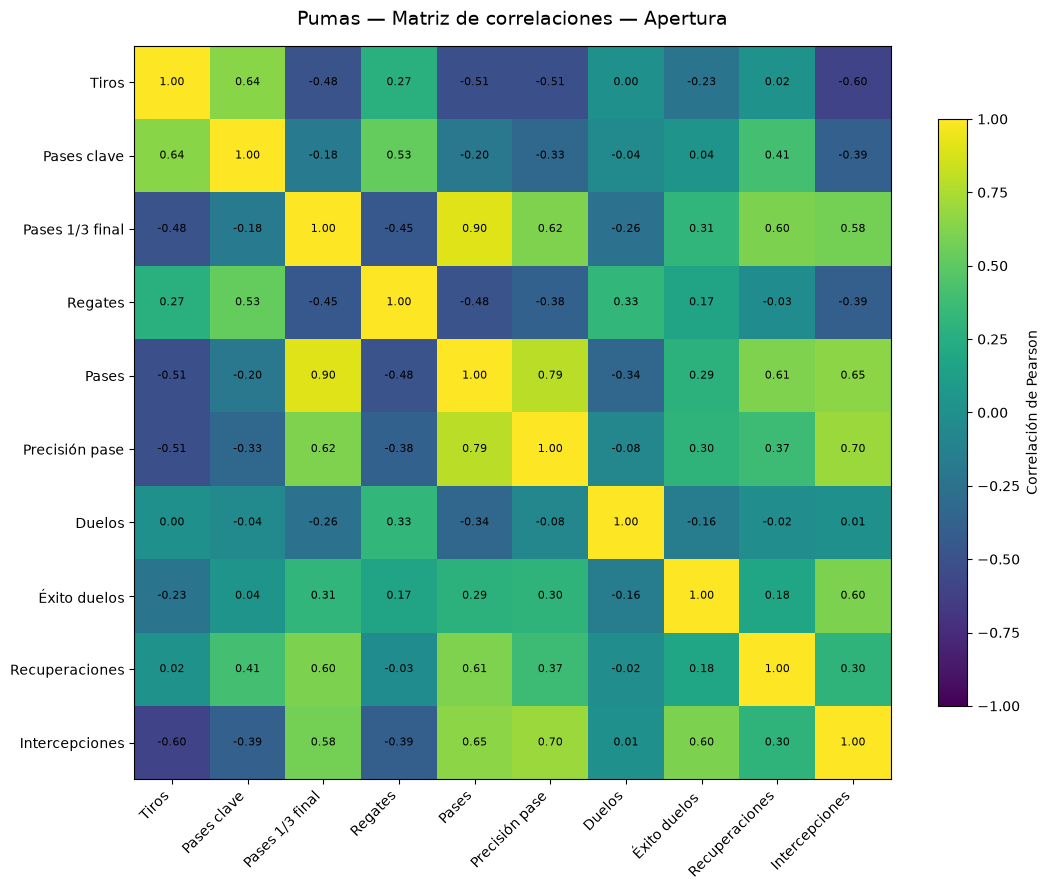

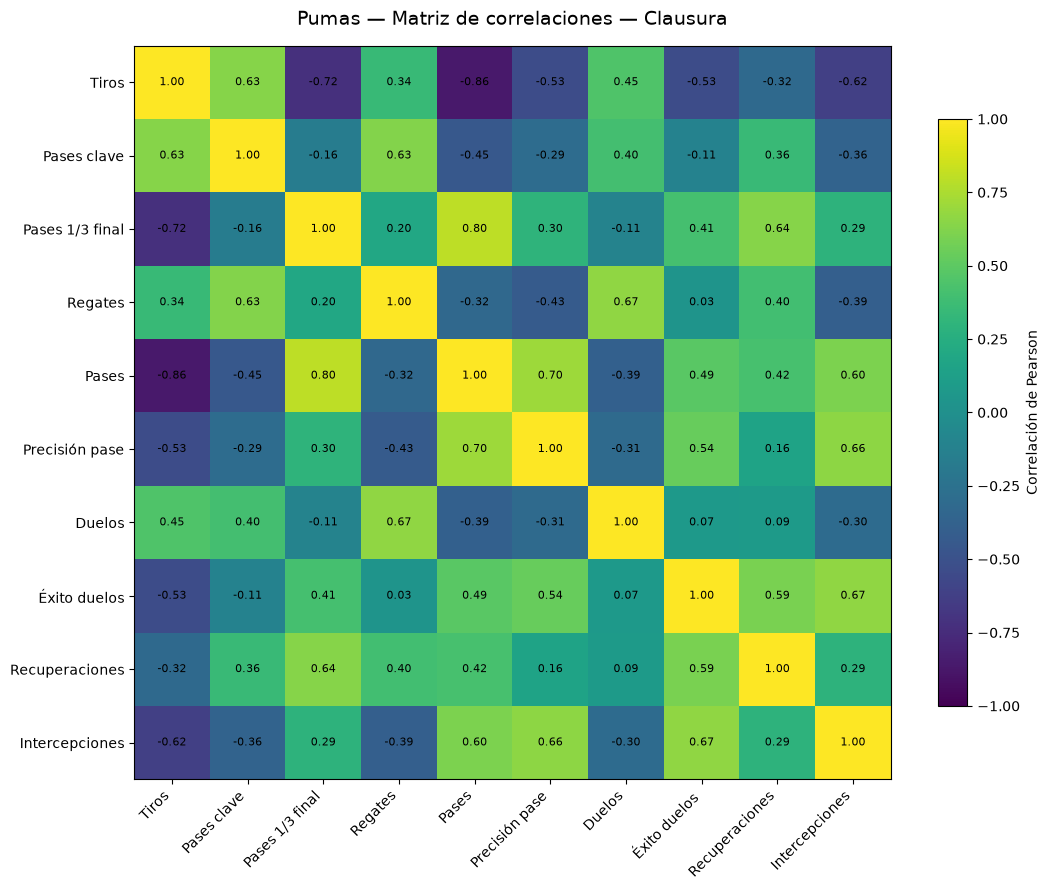

In [8]:
# ============================================================
# MATRICES DE CORRELACIÓN — VISUALIZACIÓN
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# Nombres cortos para facilitar la lectura
FEATURE_LABELS = {
    "shots_per90": "Tiros",
    "key_passes_per90": "Pases clave",
    "passes_in_final_third_per90": "Pases 1/3 final",
    "successful_dribbles_per90": "Regates",
    "passes_per90": "Pases",
    "pass_accuracy": "Precisión pase",
    "total_duels_per90": "Duelos",
    "duel_success": "Éxito duelos",
    "ball_recoveries_per90": "Recuperaciones",
    "interceptions_per90": "Intercepciones",
}


def plot_correlation_matrix(corr_matrix, title):

    labels = [
        FEATURE_LABELS[col]
        for col in corr_matrix.columns
    ]

    fig, ax = plt.subplots(figsize=(11, 9))

    image = ax.imshow(
        corr_matrix.values,
        vmin=-1,
        vmax=1,
        aspect="auto",
    )

    # Ejes
    ax.set_xticks(
        np.arange(len(labels)),
        labels=labels,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(
        np.arange(len(labels)),
        labels=labels,
    )

    # Valores de correlación
    for i in range(len(labels)):
        for j in range(len(labels)):

            value = corr_matrix.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    # Barra de escala
    cbar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.8,
    )

    cbar.set_label(
        "Correlación de Pearson"
    )

    ax.set_title(
        title,
        fontsize=14,
        pad=15,
    )

    fig.tight_layout()

    plt.show()


# ------------------------------------------------------------
# APERTURA
# ------------------------------------------------------------

plot_correlation_matrix(
    corr_apertura,
    "Pumas — Matriz de correlaciones — Apertura",
)


# ------------------------------------------------------------
# CLAUSURA
# ------------------------------------------------------------

plot_correlation_matrix(
    corr_clausura,
    "Pumas — Matriz de correlaciones — Clausura",
)

In [9]:
# ============================================================
# PASO 5 — ESTANDARIZACIÓN + PCA
# Apertura y Clausura por separado
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def run_pca(X, tournament):

    # --------------------------------------------------------
    # 1. ESTANDARIZACIÓN
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)


    # Comprobación aproximada
    print(f"\n=== {tournament.upper()} ===")

    print(
        "Media estandarizada máxima (abs):",
        np.abs(X_scaled.mean(axis=0)).max()
    )

    print(
        "Desv. estándar:",
        np.round(
            X_scaled.std(axis=0),
            3
        )
    )


    # --------------------------------------------------------
    # 2. PCA COMPLETO
    # --------------------------------------------------------

    pca = PCA()

    X_pca = pca.fit_transform(X_scaled)


    # --------------------------------------------------------
    # 3. VARIANZA EXPLICADA
    # --------------------------------------------------------

    explained = (
        pca.explained_variance_ratio_
    )

    cumulative = np.cumsum(explained)

    eigenvalues = (
        pca.explained_variance_
    )


    variance_table = pd.DataFrame({
        "component": [
            f"PC{i}"
            for i in range(
                1,
                len(explained) + 1
            )
        ],
        "eigenvalue": eigenvalues,
        "explained_variance": explained,
        "explained_pct": explained * 100,
        "cumulative_pct": cumulative * 100,
    })


    return {
        "scaler": scaler,
        "pca": pca,
        "X_scaled": X_scaled,
        "X_pca": X_pca,
        "variance": variance_table,
    }


# ------------------------------------------------------------
# APERTURA
# ------------------------------------------------------------

pca_result_apertura = run_pca(
    X_apertura,
    "Apertura",
)


# ------------------------------------------------------------
# CLAUSURA
# ------------------------------------------------------------

pca_result_clausura = run_pca(
    X_clausura,
    "Clausura",
)


# ------------------------------------------------------------
# TABLAS DE VARIANZA
# ------------------------------------------------------------

print(
    "\n=== VARIANZA EXPLICADA — APERTURA ==="
)

print(
    pca_result_apertura["variance"]
    .round(4)
    .to_string(index=False)
)


print(
    "\n=== VARIANZA EXPLICADA — CLAUSURA ==="
)

print(
    pca_result_clausura["variance"]
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# NÚMERO DE COMPONENTES PARA DISTINTOS UMBRALES
# ------------------------------------------------------------

def components_for_threshold(
    variance_table,
    threshold
):

    return int(
        np.argmax(
            variance_table[
                "cumulative_pct"
            ].values >= threshold
        )
        + 1
    )


print("\n=== COMPONENTES NECESARIOS ===")

for threshold in [70, 80, 90]:

    n_ap = components_for_threshold(
        pca_result_apertura["variance"],
        threshold,
    )

    n_cl = components_for_threshold(
        pca_result_clausura["variance"],
        threshold,
    )

    print(
        f"{threshold}% → "
        f"Apertura: {n_ap} PC | "
        f"Clausura: {n_cl} PC"
    )


=== APERTURA ===
Media estandarizada máxima (abs): 1.7701889337078885e-15
Desv. estándar: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

=== CLAUSURA ===
Media estandarizada máxima (abs): 5.057682667736824e-16
Desv. estándar: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

=== VARIANZA EXPLICADA — APERTURA ===
component  eigenvalue  explained_variance  explained_pct  cumulative_pct
      PC1      4.6908              0.4430        44.3019         44.3019
      PC2      1.9912              0.1881        18.8062         63.1080
      PC3      1.4076              0.1329        13.2942         76.4022
      PC4      1.0689              0.1010        10.0952         86.4974
      PC5      0.5538              0.0523         5.2305         91.7279
      PC6      0.4031              0.0381         3.8066         95.5345
      PC7      0.2156              0.0204         2.0367         97.5712
      PC8      0.1457              0.0138         1.3756         98.9469
      PC9      0.0780              0.0074         0.7364   

In [10]:
N_COMPONENTS = 5

In [11]:
# ============================================================
# PASO 7 — PREPARACIÓN PARA COMPARAR CLUSTERING
# K-Means vs GMM vs DBSCAN
# ============================================================

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)


# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------

N_COMPONENTS_CLUSTER = 5

CLUSTER_FEATURES = [
    "PC1",
    "PC2",
    "PC3",
    "PC4",
    "PC5",
]


# ------------------------------------------------------------
# 1. CREAR COORDENADAS PCA POR JUGADOR
# ------------------------------------------------------------

def build_pca_scores(
    population,
    pca_result,
    tournament,
    n_components=5,
):

    scores = pd.DataFrame(
        pca_result["X_pca"][:, :n_components],
        columns=[
            f"PC{i}"
            for i in range(1, n_components + 1)
        ],
    )

    metadata = (
        population[
            [
                "player_id",
                "player_name",
                "position_group",
                "total_valid_minutes",
            ]
        ]
        .reset_index(drop=True)
    )

    result = pd.concat(
        [metadata, scores],
        axis=1,
    )

    result.insert(
        0,
        "tournament",
        tournament,
    )

    return result


pca_scores_apertura = build_pca_scores(
    pca_apertura,
    pca_result_apertura,
    "Apertura",
    N_COMPONENTS_CLUSTER,
)

pca_scores_clausura = build_pca_scores(
    pca_clausura,
    pca_result_clausura,
    "Clausura",
    N_COMPONENTS_CLUSTER,
)


# ------------------------------------------------------------
# 2. FUNCIÓN GENERAL DE MÉTRICAS
# ------------------------------------------------------------

def clustering_metrics(X, labels):

    labels = np.asarray(labels)

    # DBSCAN utiliza -1 para ruido
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    unique_clusters = np.unique(labels_eval)

    n_clusters = len(unique_clusters)
    n_noise = int((labels == -1).sum())

    # No se pueden calcular estas métricas
    # si existe menos de 2 clusters
    if (
        n_clusters < 2
        or len(X_eval) <= n_clusters
    ):

        return {
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,

        "silhouette":
            silhouette_score(
                X_eval,
                labels_eval,
            ),

        "davies_bouldin":
            davies_bouldin_score(
                X_eval,
                labels_eval,
            ),

        "calinski_harabasz":
            calinski_harabasz_score(
                X_eval,
                labels_eval,
            ),
    }


# ------------------------------------------------------------
# 3. COMPROBACIONES
# ------------------------------------------------------------

print("=== MATRICES PARA CLUSTERING ===")

print(
    "Apertura:",
    pca_scores_apertura[
        CLUSTER_FEATURES
    ].shape
)

print(
    "Clausura:",
    pca_scores_clausura[
        CLUSTER_FEATURES
    ].shape
)


print(
    "\nMissing Apertura:",
    pca_scores_apertura[
        CLUSTER_FEATURES
    ].isna().sum().sum()
)

print(
    "Missing Clausura:",
    pca_scores_clausura[
        CLUSTER_FEATURES
    ].isna().sum().sum()
)


print(
    "\nVarianza PCA utilizada:"
)

print(
    "Apertura:",
    round(
        pca_result_apertura[
            "variance"
        ]
        .iloc[:5]["explained_pct"]
        .sum(),
        2,
    ),
    "%"
)

print(
    "Clausura:",
    round(
        pca_result_clausura[
            "variance"
        ]
        .iloc[:5]["explained_pct"]
        .sum(),
        2,
    ),
    "%"
)

=== MATRICES PARA CLUSTERING ===
Apertura: (18, 5)
Clausura: (18, 5)

Missing Apertura: 0
Missing Clausura: 0

Varianza PCA utilizada:
Apertura: 91.73 %
Clausura: 94.17 %


In [12]:
# ============================================================
# PASO 8 — BENCHMARK DE CLUSTERING
# K-Means vs GMM vs DBSCAN
# ============================================================

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture


# ------------------------------------------------------------
# FUNCIÓN DE BENCHMARK
# ------------------------------------------------------------

def benchmark_clustering(
    scores,
    tournament,
):

    X = (
        scores[CLUSTER_FEATURES]
        .to_numpy()
    )

    results = []

    models = {}


    # ========================================================
    # 1. K-MEANS
    # ========================================================

    for k in [2, 3, 4, 5]:

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=50,
        )

        labels = model.fit_predict(X)

        metrics = clustering_metrics(
            X,
            labels,
        )

        key = f"kmeans_k{k}"

        models[key] = {
            "model": model,
            "labels": labels,
        }

        results.append({
            "tournament": tournament,
            "algorithm": "KMeans",
            "configuration": f"k={k}",
            **metrics,
            "inertia": model.inertia_,
            "bic": np.nan,
            "aic": np.nan,
        })


    # ========================================================
    # 2. GAUSSIAN MIXTURE MODEL
    # ========================================================

    for k in [2, 3, 4, 5]:

        model = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=42,
            n_init=20,
            reg_covar=1e-5,
        )

        labels = model.fit_predict(X)

        metrics = clustering_metrics(
            X,
            labels,
        )

        key = f"gmm_k{k}"

        models[key] = {
            "model": model,
            "labels": labels,

            # Probabilidad de pertenencia
            "probabilities":
                model.predict_proba(X),
        }

        results.append({
            "tournament": tournament,
            "algorithm": "GMM",
            "configuration": f"k={k}",
            **metrics,
            "inertia": np.nan,
            "bic": model.bic(X),
            "aic": model.aic(X),
        })


    # ========================================================
    # 3. DBSCAN
    # ========================================================

    # PC scores no necesariamente tienen la misma varianza
    # por componente. Esto es intencional: componentes que
    # explican más información conservan mayor peso.
    
    eps_values = [
        0.75,
        1.00,
        1.25,
        1.50,
        1.75,
        2.00,
        2.25,
        2.50,
        2.75,
        3.00,
    ]

    min_samples_values = [
        2,
        3,
        4,
    ]

    for eps in eps_values:

        for min_samples in min_samples_values:

            model = DBSCAN(
                eps=eps,
                min_samples=min_samples,
            )

            labels = model.fit_predict(X)

            metrics = clustering_metrics(
                X,
                labels,
            )

            key = (
                f"dbscan_eps{eps}"
                f"_min{min_samples}"
            )

            models[key] = {
                "model": model,
                "labels": labels,
            }

            results.append({
                "tournament": tournament,
                "algorithm": "DBSCAN",
                "configuration":
                    f"eps={eps}, min={min_samples}",
                **metrics,
                "inertia": np.nan,
                "bic": np.nan,
                "aic": np.nan,
            })


    return (
        pd.DataFrame(results),
        models,
    )


# ------------------------------------------------------------
# APERTURA
# ------------------------------------------------------------

benchmark_apertura, models_apertura = (
    benchmark_clustering(
        pca_scores_apertura,
        "Apertura",
    )
)


# ------------------------------------------------------------
# CLAUSURA
# ------------------------------------------------------------

benchmark_clausura, models_clausura = (
    benchmark_clustering(
        pca_scores_clausura,
        "Clausura",
    )
)


# ------------------------------------------------------------
# UNIR RESULTADOS
# ------------------------------------------------------------

benchmark_all = pd.concat(
    [
        benchmark_apertura,
        benchmark_clausura,
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# MOSTRAR K-MEANS + GMM COMPLETOS
# ------------------------------------------------------------

for tournament in [
    "Apertura",
    "Clausura",
]:

    print(
        f"\n{'='*70}"
    )

    print(
        f"{tournament.upper()} — K-MEANS / GMM"
    )

    print(
        f"{'='*70}"
    )

    display(
        benchmark_all[
            (
                benchmark_all["tournament"]
                == tournament
            )
            &
            (
                benchmark_all["algorithm"]
                .isin(["KMeans", "GMM"])
            )
        ][
            [
                "algorithm",
                "configuration",
                "n_clusters",
                "n_noise",
                "silhouette",
                "davies_bouldin",
                "calinski_harabasz",
                "bic",
                "aic",
            ]
        ]
        .round(3)
    )


# ------------------------------------------------------------
# DBSCAN:
# Mostrar sólo configuraciones que realmente generaron
# 2 o más clusters y pudieron calcular silhouette
# ------------------------------------------------------------

for tournament in [
    "Apertura",
    "Clausura",
]:

    valid_dbscan = (
        benchmark_all[
            (
                benchmark_all["tournament"]
                == tournament
            )
            &
            (
                benchmark_all["algorithm"]
                == "DBSCAN"
            )
            &
            (
                benchmark_all["n_clusters"]
                >= 2
            )
            &
            (
                benchmark_all["silhouette"]
                .notna()
            )
        ]
        .sort_values(
            "silhouette",
            ascending=False,
        )
    )


    print(
        f"\n{'='*70}"
    )

    print(
        f"{tournament.upper()} — DBSCAN "
        f"(configuraciones válidas)"
    )

    print(
        f"{'='*70}"
    )


    if len(valid_dbscan) == 0:

        print(
            "DBSCAN no encontró una "
            "partición válida con esta rejilla."
        )

    else:

        display(
            valid_dbscan[
                [
                    "configuration",
                    "n_clusters",
                    "n_noise",
                    "silhouette",
                    "davies_bouldin",
                    "calinski_harabasz",
                ]
            ]
            .head(10)
            .round(3)
        )


APERTURA — K-MEANS / GMM


,algorithm,configuration,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,bic,aic
0,KMeans,k=2,2,0,0.301,1.185,10.170,NaN,NaN
1,KMeans,k=3,3,0,0.289,1.338,7.974,NaN,NaN
2,KMeans,k=4,4,0,0.251,1.092,7.272,NaN,NaN
3,KMeans,k=5,5,0,0.222,1.117,6.929,NaN,NaN
4,GMM,k=2,2,0,0.290,1.163,9.831,339.662,303.157
5,GMM,k=3,3,0,0.274,1.196,7.095,246.109,190.906
6,GMM,k=4,4,0,0.229,1.283,6.204,159.805,85.904
7,GMM,k=5,5,0,0.161,1.153,6.304,88.973,-3.626



CLAUSURA — K-MEANS / GMM


,algorithm,configuration,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,bic,aic
38,KMeans,k=2,2,0,0.315,1.142,9.827,NaN,NaN
39,KMeans,k=3,3,0,0.327,0.988,10.053,NaN,NaN
40,KMeans,k=4,4,0,0.327,0.804,9.479,NaN,NaN
41,KMeans,k=5,5,0,0.363,0.782,10.620,NaN,NaN
42,GMM,k=2,2,0,0.329,0.984,8.901,280.238,243.733
43,GMM,k=3,3,0,0.313,1.023,9.784,247.869,192.666
44,GMM,k=4,4,0,0.296,0.896,9.018,157.360,83.459
45,GMM,k=5,5,0,0.268,1.044,7.560,49.638,-42.960



APERTURA — DBSCAN (configuraciones válidas)


,configuration,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
17,"eps=1.5, min=2",2,14,0.569,0.438,10.402
24,"eps=2.0, min=3",2,11,0.518,0.622,12.108
20,"eps=1.75, min=2",4,9,0.374,0.705,9.667
28,"eps=2.25, min=4",2,7,0.367,0.911,8.884
31,"eps=2.5, min=4",2,7,0.358,0.871,7.241
23,"eps=2.0, min=2",4,7,0.347,0.762,8.494



CLAUSURA — DBSCAN (configuraciones válidas)


,configuration,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
49,"eps=1.0, min=2",2,14,0.839,0.162,75.165
52,"eps=1.25, min=2",2,14,0.839,0.162,75.165
56,"eps=1.5, min=3",2,12,0.611,0.463,16.827
59,"eps=1.75, min=3",2,12,0.611,0.463,16.827
62,"eps=2.0, min=3",2,11,0.604,0.484,18.959
58,"eps=1.75, min=2",4,8,0.598,0.440,19.004
55,"eps=1.5, min=2",4,8,0.598,0.440,19.004
61,"eps=2.0, min=2",5,5,0.482,0.589,13.805
66,"eps=2.25, min=4",3,3,0.378,0.848,11.179
69,"eps=2.5, min=4",3,3,0.378,0.848,11.179


In [13]:
# ============================================================
# PASO 9 — COMPOSICIÓN DE CLUSTERS
# Comparar soluciones útiles: k = 3, 4, 5
# ============================================================

def cluster_composition(
    scores,
    labels,
    algorithm,
    k,
    tournament,
):

    df = scores[
        [
            "player_name",
            "position_group",
            "total_valid_minutes",
        ]
    ].copy()

    df["cluster"] = labels

    rows = []

    for cluster in sorted(df["cluster"].unique()):

        temp = df[df["cluster"] == cluster]

        positions = (
            temp["position_group"]
            .value_counts()
            .sort_index()
            .to_dict()
        )

        rows.append({
            "tournament": tournament,
            "algorithm": algorithm,
            "k": k,
            "cluster": cluster,
            "n_players": len(temp),

            "DF": positions.get("DF", 0),
            "MF": positions.get("MF", 0),
            "FW": positions.get("FW", 0),

            "median_minutes":
                temp["total_valid_minutes"].median(),

            "players":
                ", ".join(
                    temp["player_name"]
                    .sort_values()
                    .tolist()
                ),
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# GENERAR TODAS LAS SOLUCIONES
# ------------------------------------------------------------

composition_tables = []


for tournament, scores, models in [

    (
        "Apertura",
        pca_scores_apertura,
        models_apertura,
    ),

    (
        "Clausura",
        pca_scores_clausura,
        models_clausura,
    ),

]:

    for k in [3, 4, 5]:

        # K-MEANS
        composition_tables.append(
            cluster_composition(
                scores,
                models[
                    f"kmeans_k{k}"
                ]["labels"],
                "KMeans",
                k,
                tournament,
            )
        )

        # GMM
        composition_tables.append(
            cluster_composition(
                scores,
                models[
                    f"gmm_k{k}"
                ]["labels"],
                "GMM",
                k,
                tournament,
            )
        )


cluster_composition_all = pd.concat(
    composition_tables,
    ignore_index=True,
)


# ------------------------------------------------------------
# RESUMEN DE TAMAÑOS
# ------------------------------------------------------------

print("=== TAMAÑO DE CLUSTERS ===")

display(
    cluster_composition_all[
        [
            "tournament",
            "algorithm",
            "k",
            "cluster",
            "n_players",
            "DF",
            "MF",
            "FW",
        ]
    ]
)


# ------------------------------------------------------------
# DETECTAR SOLUCIONES CON CLUSTERS MUY PEQUEÑOS
# ------------------------------------------------------------

solution_quality = (
    cluster_composition_all
    .groupby(
        [
            "tournament",
            "algorithm",
            "k",
        ]
    )
    .agg(
        smallest_cluster=(
            "n_players",
            "min",
        ),
        largest_cluster=(
            "n_players",
            "max",
        ),
        n_clusters=(
            "cluster",
            "nunique",
        ),
    )
    .reset_index()
)


print(
    "\n=== BALANCE DE LAS SOLUCIONES ==="
)

display(solution_quality)


# ------------------------------------------------------------
# COMPOSICIÓN COMPLETA
# ------------------------------------------------------------

print(
    "\n=== JUGADORES POR CLUSTER ==="
)

display(
    cluster_composition_all[
        [
            "tournament",
            "algorithm",
            "k",
            "cluster",
            "n_players",
            "DF",
            "MF",
            "FW",
            "players",
        ]
    ]
)

=== TAMAÑO DE CLUSTERS ===


,tournament,algorithm,k,cluster,n_players,DF,MF,FW
0,Apertura,KMeans,3,0,4,2,1,1
1,Apertura,KMeans,3,1,9,4,5,0
2,Apertura,KMeans,3,2,5,1,0,4
3,Apertura,GMM,3,0,10,4,6,0
4,Apertura,GMM,3,1,5,1,0,4
5,Apertura,GMM,3,2,3,2,0,1
6,Apertura,KMeans,4,0,8,4,4,0
7,Apertura,KMeans,4,1,6,2,2,2
8,Apertura,KMeans,4,2,2,1,0,1
9,Apertura,KMeans,4,3,2,0,0,2



=== BALANCE DE LAS SOLUCIONES ===


,tournament,algorithm,k,smallest_cluster,largest_cluster,n_clusters
0,Apertura,GMM,3,3,10,3
1,Apertura,GMM,4,2,8,4
2,Apertura,GMM,5,3,5,5
3,Apertura,KMeans,3,4,9,3
4,Apertura,KMeans,4,2,8,4
5,Apertura,KMeans,5,2,6,5
6,Clausura,GMM,3,4,9,3
7,Clausura,GMM,4,3,6,4
8,Clausura,GMM,5,3,4,5
9,Clausura,KMeans,3,5,8,3



=== JUGADORES POR CLUSTER ===


,tournament,algorithm,k,cluster,n_players,DF,MF,FW,players
0,Apertura,KMeans,3,0,4,2,1,1,"Aaron Ramsey, José Juan Macías Guzmán, Pablo A..."
1,Apertura,KMeans,3,1,9,4,5,0,"Adalberto Eliécer Carrasquilla Alcázar, José L..."
2,Apertura,KMeans,3,2,5,1,0,4,"Alan Medina Camacho, Guillermo Martínez Ayala,..."
3,Apertura,GMM,3,0,10,4,6,0,"Aaron Ramsey, Adalberto Eliécer Carrasquilla A..."
4,Apertura,GMM,3,1,5,1,0,4,"Alan Medina Camacho, Guillermo Martínez Ayala,..."
5,Apertura,GMM,3,2,3,2,0,1,"José Juan Macías Guzmán, Pablo Alfonso Monroy ..."
6,Apertura,KMeans,4,0,8,4,4,0,"Adalberto Eliécer Carrasquilla Alcázar, José L..."
7,Apertura,KMeans,4,1,6,2,2,2,"Aaron Ramsey, Alan Medina Camacho, Jorge Ruval..."
8,Apertura,KMeans,4,2,2,1,0,1,"José Juan Macías Guzmán, Pablo Alfonso Monroy ..."
9,Apertura,KMeans,4,3,2,0,0,2,"Guillermo Martínez Ayala, Santiago López López"


In [14]:
# ============================================================
# PASO 10 — ESTABILIDAD DE CLUSTERING
# K-Means vs GMM
# k = 3, 4, 5
# ============================================================

from sklearn.metrics import adjusted_rand_score
from itertools import combinations


RANDOM_STATES = range(50)
K_VALUES = [3, 4, 5]


def clustering_stability(scores, tournament):

    X = scores[CLUSTER_FEATURES].to_numpy()

    rows = []

    # ========================================================
    # K-MEANS
    # ========================================================

    for k in K_VALUES:

        solutions = []

        for seed in RANDOM_STATES:

            model = KMeans(
                n_clusters=k,
                random_state=seed,
                n_init=20,
            )

            labels = model.fit_predict(X)

            solutions.append(labels)

        ari_values = [
            adjusted_rand_score(a, b)
            for a, b in combinations(
                solutions,
                2,
            )
        ]

        rows.append({
            "tournament": tournament,
            "algorithm": "KMeans",
            "k": k,
            "mean_ARI": np.mean(ari_values),
            "median_ARI": np.median(ari_values),
            "min_ARI": np.min(ari_values),
            "std_ARI": np.std(ari_values),
        })


    # ========================================================
    # GMM
    # ========================================================

    for k in K_VALUES:

        solutions = []

        for seed in RANDOM_STATES:

            model = GaussianMixture(
                n_components=k,
                covariance_type="full",
                random_state=seed,
                n_init=10,
                reg_covar=1e-5,
            )

            labels = model.fit_predict(X)

            solutions.append(labels)

        ari_values = [
            adjusted_rand_score(a, b)
            for a, b in combinations(
                solutions,
                2,
            )
        ]

        rows.append({
            "tournament": tournament,
            "algorithm": "GMM",
            "k": k,
            "mean_ARI": np.mean(ari_values),
            "median_ARI": np.median(ari_values),
            "min_ARI": np.min(ari_values),
            "std_ARI": np.std(ari_values),
        })


    return pd.DataFrame(rows)


# ------------------------------------------------------------
# EJECUTAR
# ------------------------------------------------------------

stability_apertura = clustering_stability(
    pca_scores_apertura,
    "Apertura",
)

stability_clausura = clustering_stability(
    pca_scores_clausura,
    "Clausura",
)

stability_all = pd.concat(
    [
        stability_apertura,
        stability_clausura,
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

print("=== ESTABILIDAD DE CLUSTERS ===")

display(
    stability_all
    .sort_values(
        [
            "tournament",
            "k",
            "algorithm",
        ]
    )
    .round(3)
)

=== ESTABILIDAD DE CLUSTERS ===


,tournament,algorithm,k,mean_ARI,median_ARI,min_ARI,std_ARI
3,Apertura,GMM,3,0.676,0.699,0.075,0.221
0,Apertura,KMeans,3,0.852,0.822,0.518,0.136
4,Apertura,GMM,4,0.545,0.553,0.055,0.210
1,Apertura,KMeans,4,0.651,0.615,0.395,0.207
5,Apertura,GMM,5,0.466,0.444,0.120,0.176
2,Apertura,KMeans,5,0.585,0.582,0.232,0.182
9,Clausura,GMM,3,0.555,0.514,0.005,0.262
6,Clausura,KMeans,3,1.000,1.000,1.000,0.000
10,Clausura,GMM,4,0.671,0.622,0.087,0.200
7,Clausura,KMeans,4,1.000,1.000,1.000,0.000


In [15]:
# ============================================================
# CORRECCIÓN — NOMBRES LEGIBLES DE LAS VARIABLES
# ============================================================

READABLE_NAMES = {
    "shots_per90": "Tiros",
    "key_passes_per90": "Pases clave",
    "passes_in_final_third_per90": "Pases 1/3 final",
    "successful_dribbles_per90": "Regates",
    "passes_per90": "Pases",
    "pass_accuracy": "Precisión pase",
    "total_duels_per90": "Duelos",
    "duel_success": "Éxito duelos",
    "ball_recoveries_per90": "Recuperaciones",
    "interceptions_per90": "Intercepciones",
}

# Volver a generar dominant_profiles
dominant_profiles = dominant_cluster_features(
    cluster_profiles,
    top_n=4,
)

# Mostrar resultados
for tournament in ["Apertura", "Clausura"]:

    for k in [3, 4, 5]:

        print(f"\n{'='*70}")
        print(f"{tournament.upper()} — K-MEANS k={k}")
        print(f"{'='*70}")

        display(
            dominant_profiles[
                (dominant_profiles["tournament"] == tournament)
                &
                (dominant_profiles["k"] == k)
            ]
            .round(2)
        )

NameError: name 'dominant_cluster_features' is not defined

In [ ]:
# ============================================================
# PASO 11 — PERFIL ESTADÍSTICO DE CLUSTERS K-MEANS
# k = 3, 4, 5
# ============================================================

def build_cluster_profiles(
    population,
    pca_result,
    models,
    tournament,
):

    # Las 10 variables originales ya estandarizadas
    Z = pd.DataFrame(
        pca_result["X_scaled"],
        columns=PCA_FEATURES,
    )

    metadata = (
        population[
            [
                "player_name",
                "position_group",
            ]
        ]
        .reset_index(drop=True)
    )

    base = pd.concat(
        [metadata, Z],
        axis=1,
    )

    all_profiles = []

    for k in [3, 4, 5]:

        df = base.copy()

        df["cluster"] = (
            models[
                f"kmeans_k{k}"
            ]["labels"]
        )

        # Media estandarizada de cada métrica
        # dentro de cada cluster
        profile = (
            df
            .groupby("cluster")[
                PCA_FEATURES
            ]
            .mean()
            .reset_index()
        )

        profile.insert(
            0,
            "k",
            k,
        )

        profile.insert(
            0,
            "tournament",
            tournament,
        )

        all_profiles.append(profile)

    return pd.concat(
        all_profiles,
        ignore_index=True,
    )


profiles_apertura = build_cluster_profiles(
    pca_apertura,
    pca_result_apertura,
    models_apertura,
    "Apertura",
)

profiles_clausura = build_cluster_profiles(
    pca_clausura,
    pca_result_clausura,
    models_clausura,
    "Clausura",
)

cluster_profiles = pd.concat(
    [
        profiles_apertura,
        profiles_clausura,
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# MOSTRAR VARIABLES DOMINANTES DE CADA CLUSTER
# ------------------------------------------------------------

def dominant_cluster_features(
    profiles,
    top_n=4,
):

    rows = []

    for _, row in profiles.iterrows():

        values = row[PCA_FEATURES]

        ranked = (
            values
            .abs()
            .sort_values(
                ascending=False
            )
            .head(top_n)
        )

        for feature in ranked.index:

            rows.append({
                "tournament":
                    row["tournament"],

                "k":
                    int(row["k"]),

                "cluster":
                    int(row["cluster"]),

                "feature":
                    READABLE_NAMES.get(
                        feature,
                        feature,
                    ),

                "z_mean":
                    row[feature],
            })

    return pd.DataFrame(rows)


dominant_profiles = (
    dominant_cluster_features(
        cluster_profiles,
        top_n=4,
    )
)


# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

for tournament in [
    "Apertura",
    "Clausura",
]:

    for k in [3, 4, 5]:

        print(
            f"\n{'='*70}"
        )

        print(
            f"{tournament.upper()} — "
            f"K-MEANS k={k}"
        )

        print(
            f"{'='*70}"
        )

        display(
            dominant_profiles[
                (
                    dominant_profiles[
                        "tournament"
                    ] == tournament
                )
                &
                (
                    dominant_profiles[
                        "k"
                    ] == k
                )
            ]
            .round(2)
        )

In [ ]:
# ============================================================
# PASO 12 — TABLA FINAL PARA INTERPRETAR K-MEANS k=5
# ============================================================

FINAL_K = 5


def final_cluster_analysis(
    population,
    pca_result,
    models,
    tournament,
):

    # Métricas originales estandarizadas
    z = pd.DataFrame(
        pca_result["X_scaled"],
        columns=PCA_FEATURES,
    )

    metadata = (
        population[
            [
                "player_id",
                "player_name",
                "position_group",
                "total_valid_minutes",
            ]
        ]
        .reset_index(drop=True)
    )

    df = pd.concat(
        [metadata, z],
        axis=1,
    )

    # Cluster definitivo
    df["cluster"] = (
        models["kmeans_k5"]["labels"]
    )

    df.insert(
        0,
        "tournament",
        tournament,
    )

    # --------------------------------------------------------
    # PERFIL MEDIO COMPLETO
    # --------------------------------------------------------

    profiles = (
        df
        .groupby("cluster")[PCA_FEATURES]
        .mean()
        .round(2)
    )

    profiles = profiles.rename(
        columns=READABLE_NAMES
    )

    # --------------------------------------------------------
    # COMPOSICIÓN
    # --------------------------------------------------------

    composition = (
        df
        .groupby("cluster")
        .agg(
            n_players=("player_name", "size"),

            players=(
                "player_name",
                lambda x: ", ".join(
                    sorted(x)
                ),
            ),
        )
    )

    return df, profiles, composition


# ------------------------------------------------------------
# APERTURA
# ------------------------------------------------------------

(
    final_players_apertura,
    final_profiles_apertura,
    final_composition_apertura,
) = final_cluster_analysis(
    pca_apertura,
    pca_result_apertura,
    models_apertura,
    "Apertura",
)


# ------------------------------------------------------------
# CLAUSURA
# ------------------------------------------------------------

(
    final_players_clausura,
    final_profiles_clausura,
    final_composition_clausura,
) = final_cluster_analysis(
    pca_clausura,
    pca_result_clausura,
    models_clausura,
    "Clausura",
)


# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------

for tournament, profiles, composition in [

    (
        "APERTURA",
        final_profiles_apertura,
        final_composition_apertura,
    ),

    (
        "CLAUSURA",
        final_profiles_clausura,
        final_composition_clausura,
    ),

]:

    print(f"\n{'='*90}")
    print(f"{tournament} — PERFILES K-MEANS k=5")
    print(f"{'='*90}")

    print("\nPERFIL ESTADÍSTICO (Z-SCORES)")
    display(profiles)

    print("\nJUGADORES")
    display(composition)

In [ ]:
# ============================================================
# PASO 12B — PERFILES DE CLUSTER EN UNIDADES ORIGINALES
# ============================================================

FINAL_K = 5


def cluster_profiles_original_units(
    population,
    models,
    tournament,
):

    # --------------------------------------------------------
    # Datos originales de los jugadores
    # --------------------------------------------------------

    df = (
        population[
            [
                "player_id",
                "player_name",
                "position_group",
                "total_valid_minutes",
                *PCA_FEATURES,
            ]
        ]
        .reset_index(drop=True)
        .copy()
    )

    # Cluster calculado previamente sobre PCA
    df["cluster"] = (
        models["kmeans_k5"]["labels"]
    )

    df.insert(
        0,
        "tournament",
        tournament,
    )

    # --------------------------------------------------------
    # Promedios en unidades originales
    # --------------------------------------------------------

    profiles = (
        df
        .groupby("cluster")[PCA_FEATURES]
        .mean()
        .reset_index()
    )

    # Convertir proporciones a porcentaje
    percentage_features = [
        "pass_accuracy",
        "duel_success",
    ]

    for feature in percentage_features:
        profiles[feature] *= 100

    # --------------------------------------------------------
    # Nombres legibles + unidades
    # --------------------------------------------------------

    readable_columns = {

        "shots_per90":
            "Tiros/90",

        "key_passes_per90":
            "Pases clave/90",

        "passes_in_final_third_per90":
            "Pases 1/3 final/90",

        "successful_dribbles_per90":
            "Regates exitosos/90",

        "passes_per90":
            "Pases/90",

        "pass_accuracy":
            "Precisión pase (%)",

        "total_duels_per90":
            "Duelos/90",

        "duel_success":
            "Éxito duelos (%)",

        "ball_recoveries_per90":
            "Recuperaciones/90",

        "interceptions_per90":
            "Intercepciones/90",
    }

    profiles = profiles.rename(
        columns=readable_columns
    )

    # Redondear
    metric_columns = [
        c
        for c in profiles.columns
        if c != "cluster"
    ]

    profiles[metric_columns] = (
        profiles[metric_columns]
        .round(2)
    )

    # --------------------------------------------------------
    # Número de jugadores
    # --------------------------------------------------------

    sizes = (
        df
        .groupby("cluster")
        .size()
        .rename("Jugadores")
        .reset_index()
    )

    profiles = (
        profiles
        .merge(
            sizes,
            on="cluster",
            how="left",
        )
    )

    # Reordenar
    profiles = profiles[
        [
            "cluster",
            "Jugadores",
            "Tiros/90",
            "Pases clave/90",
            "Pases 1/3 final/90",
            "Regates exitosos/90",
            "Pases/90",
            "Precisión pase (%)",
            "Duelos/90",
            "Éxito duelos (%)",
            "Recuperaciones/90",
            "Intercepciones/90",
        ]
    ]

    return df, profiles


# ------------------------------------------------------------
# APERTURA
# ------------------------------------------------------------

(
    cluster_players_apertura,
    cluster_profiles_apertura_original,
) = cluster_profiles_original_units(
    pca_apertura,
    models_apertura,
    "Apertura",
)


# ------------------------------------------------------------
# CLAUSURA
# ------------------------------------------------------------

(
    cluster_players_clausura,
    cluster_profiles_clausura_original,
) = cluster_profiles_original_units(
    pca_clausura,
    models_clausura,
    "Clausura",
)


# ------------------------------------------------------------
# MOSTRAR RESULTADOS
# ------------------------------------------------------------

print(
    "\n=== APERTURA — "
    "PERFILES EN UNIDADES FUTBOLÍSTICAS ==="
)

display(
    cluster_profiles_apertura_original
)


print(
    "\n=== CLAUSURA — "
    "PERFILES EN UNIDADES FUTBOLÍSTICAS ==="
)

display(
    cluster_profiles_clausura_original
)

In [ ]:
# ============================================================
# PASO 13 — RESUMEN INTERPRETABLE COMPLETO DE LOS CLUSTERS
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

for tournament, profiles in [
    ("APERTURA", cluster_profiles_apertura_original),
    ("CLAUSURA", cluster_profiles_clausura_original),
]:

    print(f"\n{'='*100}")
    print(tournament)
    print(f"{'='*100}")

    for _, row in profiles.iterrows():

        print(f"\nCLUSTER {int(row['cluster'])} — {int(row['Jugadores'])} jugadores")

        print(
            f"Tiros: {row['Tiros/90']:.2f}/90 | "
            f"Pases clave: {row['Pases clave/90']:.2f}/90 | "
            f"Pases 1/3 final: {row['Pases 1/3 final/90']:.2f}/90"
        )

        print(
            f"Regates exitosos: {row['Regates exitosos/90']:.2f}/90 | "
            f"Pases: {row['Pases/90']:.2f}/90 | "
            f"Precisión: {row['Precisión pase (%)']:.1f}%"
        )

        print(
            f"Duelos: {row['Duelos/90']:.2f}/90 | "
            f"Éxito duelos: {row['Éxito duelos (%)']:.1f}% | "
            f"Recuperaciones: {row['Recuperaciones/90']:.2f}/90 | "
            f"Intercepciones: {row['Intercepciones/90']:.2f}/90"
        )

In [ ]:
# ============================================================
# PASO 14 — JUGADORES POR PERFIL
# ============================================================

PROFILE_NAMES = {
    "Apertura": {
        0: "Circulador defensivo",
        1: "Desequilibrante creativo",
        2: "Jugador de disputa",
        3: "Progresor recuperador",
        4: "Finalizador asociativo",
    },

    "Clausura": {
        0: "Circulador defensivo",
        1: "Finalizador directo",
        2: "Progresor recuperador",
        3: "Circulador de apoyo",
        4: "Atacante de duelo",
    },
}


def show_players_by_profile(df, tournament):

    print(f"\n{'='*90}")
    print(tournament.upper())
    print(f"{'='*90}")

    for cluster in sorted(df["cluster"].unique()):

        profile = PROFILE_NAMES[tournament][cluster]

        players = (
            df[df["cluster"] == cluster]
            .sort_values(
                ["position_group", "player_name"]
            )
        )

        print(
            f"\nCLUSTER {cluster} — "
            f"{profile.upper()} "
            f"({len(players)} jugadores)"
        )

        for _, row in players.iterrows():

            print(
                f"  {row['player_name']} "
                f"| {row['position_group']} "
                f"| {row['total_valid_minutes']:.0f} min"
            )


show_players_by_profile(
    cluster_players_apertura,
    "Apertura",
)

show_players_by_profile(
    cluster_players_clausura,
    "Clausura",
)

In [ ]:
# ============================================================
# DESCRIPCIÓN FUTBOLÍSTICA DE LOS PERFILES
# ============================================================

PROFILE_DESCRIPTIONS = {

    "Apertura": {

        0: (
            "Perfil de circulación y equilibrio defensivo. "
            "Alto volumen y precisión de pase, buena presencia "
            "en intercepciones y baja producción ofensiva."
        ),

        1: (
            "Perfil de desequilibrio y creación. Destaca por "
            "el regate, los pases clave y la eficiencia en duelos, "
            "con menor volumen de circulación."
        ),

        2: (
            "Perfil orientado a la disputa directa. Registra un "
            "alto volumen de duelos y poca participación en la "
            "circulación y progresión del balón."
        ),

        3: (
            "Perfil de progresión, creación y recuperación. "
            "Combina alto volumen de pase, presencia en el último "
            "tercio, pases clave y recuperación del balón."
        ),

        4: (
            "Perfil de orientación ofensiva y finalización. "
            "Destaca por su volumen de tiro y generación de pases "
            "clave, con participación asociativa intermedia."
        ),
    },

    "Clausura": {

        0: (
            "Perfil de circulación y equilibrio defensivo. "
            "Alto volumen y precisión de pase, fuerte presencia "
            "en intercepciones y baja producción ofensiva."
        ),

        1: (
            "Perfil de finalización directa. Destaca por un alto "
            "volumen de tiro con baja participación en la circulación "
            "y progresión del balón."
        ),

        2: (
            "Perfil de progresión y recuperación. Combina alto "
            "volumen de pase, progresión hacia el último tercio, "
            "creación y una elevada recuperación del balón."
        ),

        3: (
            "Perfil de apoyo en la circulación. Participa en la "
            "progresión y el movimiento del balón, con menor producción "
            "en creación, finalización y recuperación."
        ),

        4: (
            "Perfil ofensivo de alta disputa. Combina un volumen "
            "muy elevado de duelos con regate, tiro y generación "
            "de pases clave."
        ),
    },
}

In [ ]:
# ============================================================
# PASO 15 — PRODUCTO ANALÍTICO FINAL PCA + CLUSTERING
# ============================================================

from pathlib import Path

OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def build_product_dataset(
    population,
    pca_scores,
    cluster_players,
    tournament,
):

    # --------------------------------------------------------
    # Identificación + métricas originales
    # --------------------------------------------------------

    base = (
        population[
            [
                "player_id",
                "player_name",
                "position_group",
                "total_valid_minutes",
                *PCA_FEATURES,
            ]
        ]
        .reset_index(drop=True)
        .copy()
    )

    # --------------------------------------------------------
    # Componentes principales
    # --------------------------------------------------------

    pcs = (
        pca_scores[
            ["PC1", "PC2", "PC3", "PC4", "PC5"]
        ]
        .reset_index(drop=True)
        .copy()
    )

    # --------------------------------------------------------
    # Cluster K-Means
    # --------------------------------------------------------

    base["cluster"] = (
        cluster_players["cluster"]
        .reset_index(drop=True)
    )

    # Nombre interpretable
    base["profile_name"] = (
        base["cluster"]
        .map(PROFILE_NAMES[tournament])
    )

    # Lectura futbolística
    base["profile_description"] = (
        base["cluster"]
        .map(PROFILE_DESCRIPTIONS[tournament])
    )

    base.insert(
        0,
        "tournament",
        tournament,
    )

    # --------------------------------------------------------
    # Unir componentes PCA
    # --------------------------------------------------------

    result = pd.concat(
        [base, pcs],
        axis=1,
    )

    return result


# ============================================================
# DATASET POR TORNEO
# ============================================================

product_apertura = build_product_dataset(
    pca_apertura,
    pca_scores_apertura,
    cluster_players_apertura,
    "Apertura",
)

product_clausura = build_product_dataset(
    pca_clausura,
    pca_scores_clausura,
    cluster_players_clausura,
    "Clausura",
)


# ============================================================
# DATASET PRINCIPAL
# ============================================================

pumas_pca_clustering = pd.concat(
    [
        product_apertura,
        product_clausura,
    ],
    ignore_index=True,
)


# ============================================================
# EXPORTAR DATASET DE JUGADORES
# ============================================================

players_file = (
    OUTPUT_DIR /
    "pumas_pca_clustering_2025_2026.csv"
)

pumas_pca_clustering.to_csv(
    players_file,
    index=False,
)


# ============================================================
# DATASET DE PERFILES — APERTURA
# ============================================================

profiles_a = (
    cluster_profiles_apertura_original
    .copy()
)

profiles_a.insert(
    0,
    "tournament",
    "Apertura",
)

profiles_a["profile_name"] = (
    profiles_a["cluster"]
    .map(PROFILE_NAMES["Apertura"])
)

profiles_a["profile_description"] = (
    profiles_a["cluster"]
    .map(PROFILE_DESCRIPTIONS["Apertura"])
)


# ============================================================
# DATASET DE PERFILES — CLAUSURA
# ============================================================

profiles_c = (
    cluster_profiles_clausura_original
    .copy()
)

profiles_c.insert(
    0,
    "tournament",
    "Clausura",
)

profiles_c["profile_name"] = (
    profiles_c["cluster"]
    .map(PROFILE_NAMES["Clausura"])
)

profiles_c["profile_description"] = (
    profiles_c["cluster"]
    .map(PROFILE_DESCRIPTIONS["Clausura"])
)


# ============================================================
# UNIR Y EXPORTAR PERFILES
# ============================================================

cluster_profiles_product = pd.concat(
    [
        profiles_a,
        profiles_c,
    ],
    ignore_index=True,
)

profiles_file = (
    OUTPUT_DIR /
    "pumas_cluster_profiles_2025_2026.csv"
)

cluster_profiles_product.to_csv(
    profiles_file,
    index=False,
)


# ============================================================
# VALIDACIONES
# ============================================================

print("=" * 80)
print("PRODUCTO ANALÍTICO PCA + CLUSTERING EXPORTADO")
print("=" * 80)

print("\nDataset de jugadores:")
print(players_file)
print(
    f"{len(pumas_pca_clustering)} filas x "
    f"{len(pumas_pca_clustering.columns)} columnas"
)

print("\nDataset de perfiles:")
print(profiles_file)
print(
    f"{len(cluster_profiles_product)} filas x "
    f"{len(cluster_profiles_product.columns)} columnas"
)


# ------------------------------------------------------------
# Comprobar que las etiquetas y descripciones existen
# ------------------------------------------------------------

assert (
    pumas_pca_clustering["profile_name"]
    .notna()
    .all()
)

assert (
    pumas_pca_clustering["profile_description"]
    .notna()
    .all()
)

assert (
    cluster_profiles_product["profile_name"]
    .notna()
    .all()
)

assert (
    cluster_profiles_product["profile_description"]
    .notna()
    .all()
)


# ------------------------------------------------------------
# Resumen final
# ------------------------------------------------------------

print("\n=== PERFILES DEL PRODUCTO ===")

display(
    cluster_profiles_product[
        [
            "tournament",
            "cluster",
            "Jugadores",
            "profile_name",
            "profile_description",
        ]
    ]
)


print("\n=== DISTRIBUCIÓN DE JUGADORES ===")

display(
    pumas_pca_clustering[
        [
            "tournament",
            "cluster",
            "profile_name",
        ]
    ]
    .value_counts()
    .reset_index(name="players")
    .sort_values(
        ["tournament", "cluster"]
    )
)